# 📊 Lab Work - 3.6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

import scipy.stats as stats

# 🔹 Task 1: Box-Cox Transformation

Skewness before: 1.3827557090430267
Skewness after: -0.0861090800264982


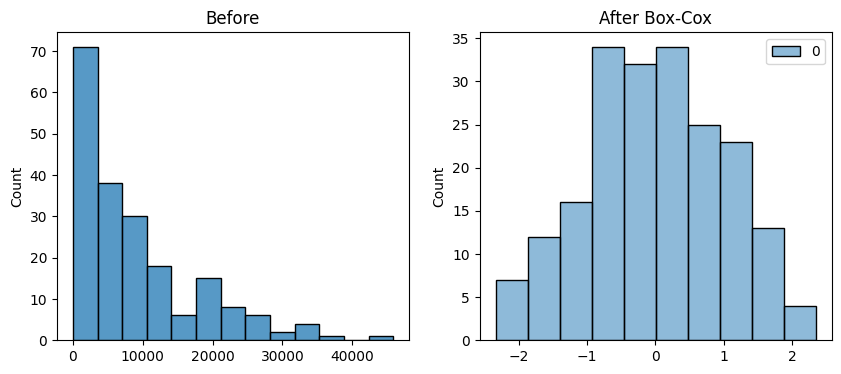

In [2]:
# Create positive skewed data
income = np.random.exponential(scale=10000, size=200)

# Before transformation
print("Skewness before:", stats.skew(income))

# Apply Box-Cox
pt = PowerTransformer(method='box-cox')
income_bc = pt.fit_transform(income.reshape(-1,1))

# After transformation
print("Skewness after:", stats.skew(income_bc.flatten()))

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(income)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(income_bc)
plt.title("After Box-Cox")

plt.show()

# 🔹 Task 2: Yeo-Johnson Transformation

Lambda value: [0.79316723]


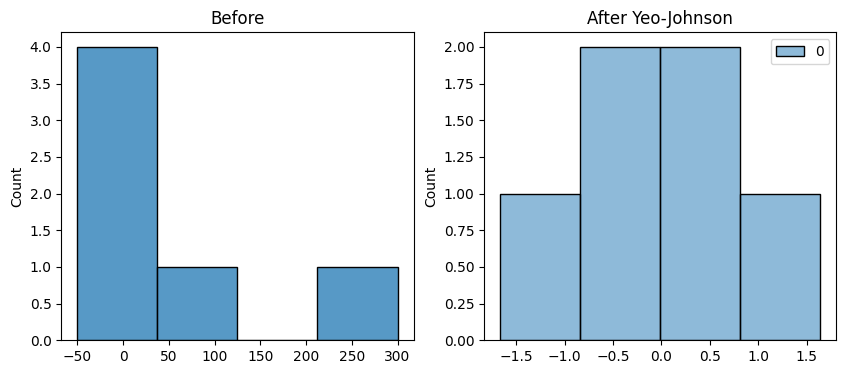

In [3]:
# Mixed data
data = np.array([-50, -10, 0, 20, 100, 300])

pt_yj = PowerTransformer(method='yeo-johnson')
data_yj = pt_yj.fit_transform(data.reshape(-1,1))

print("Lambda value:", pt_yj.lambdas_)

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(data_yj)
plt.title("After Yeo-Johnson")

plt.show()

# 🔹 Task 3: Comparison

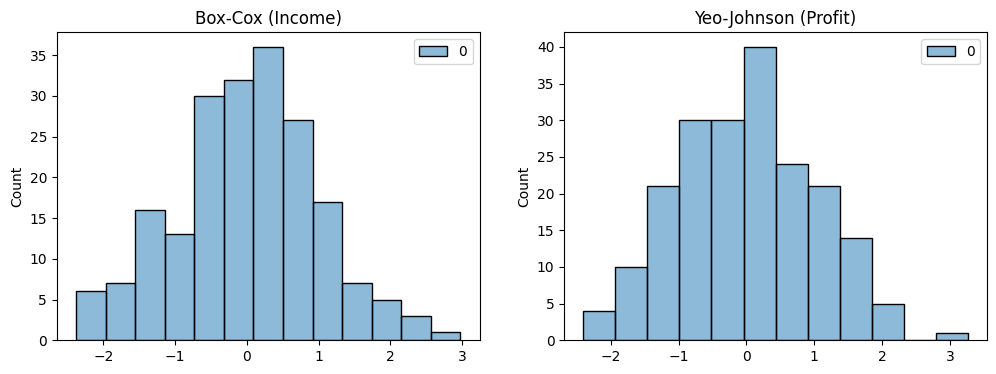

In [4]:
# Income (positive)
income = np.random.exponential(scale=10000, size=200)

# Profit (can be negative)
profit = np.random.normal(loc=0, scale=5000, size=200)

# Transformations
bc = PowerTransformer(method='box-cox')
income_bc = bc.fit_transform(income.reshape(-1,1))

yj = PowerTransformer(method='yeo-johnson')
profit_yj = yj.fit_transform(profit.reshape(-1,1))

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(income_bc)
plt.title("Box-Cox (Income)")

plt.subplot(1,2,2)
sns.histplot(profit_yj)
plt.title("Yeo-Johnson (Profit)")

plt.show()

**Conclusion:**
- Box-Cox → Only positive data
- Yeo-Johnson → Works with negative & zero

# 🔹 Task 4: ColumnTransformer Pipeline

In [5]:
# Dataset
df = pd.DataFrame({
    'Age': [25, 32, 47, 51],
    'Salary': [50000, 60000, 80000, 90000],
    'Gender': ['M', 'F', 'F', 'M'],
    'City': ['Surat', 'Mumbai', 'Delhi', 'Surat']
})

num_cols = ['Age', 'Salary']
cat_cols = ['Gender', 'City']

ct = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

result = ct.fit_transform(df)

print("Transformed Shape:", result.shape)
print(result)

Transformed Shape: (4, 7)
[[-1.29241939 -1.26491106  0.          1.          0.          0.
   1.        ]
 [-0.63446043 -0.63245553  1.          0.          0.          1.
   0.        ]
 [ 0.77545163  0.63245553  1.          0.          1.          0.
   0.        ]
 [ 1.15142818  1.26491106  0.          1.          0.          0.
   1.        ]]


# 🔹 Task 5: Full ML Pipeline

In [6]:
# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Train
pipeline.fit(X_train, y_train)

# Evaluate
accuracy = pipeline.score(X_test, y_test)

print("Accuracy:", accuracy)
print("Feature shape:", X.shape)

Accuracy: 0.9666666666666667
Feature shape: (150, 4)
